In [13]:
import pandas as pd


data = pd.read_csv('/Users/jihyunpark/Documents/Columbia/2026 Spring/Bayesian/HW3/data.csv', header=None)
data.head()


,0
0,4
1,18
2,16
3,17
4,18


In [14]:
X = data[0].values
X

array([ 4, 18, 16, ...,  3,  3, 17], shape=(2000,))

In [2]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [20]:
def initialize(K):
    pi = np.ones(K) / K
    theta = np.linspace(1/(K+1), K/(K+1), K)  # stays away from 0 and 1
    return pi, theta

In [16]:
def e_step(X, pi, theta):
    n, K = len(X), len(pi)
    log_R = np.zeros((n, K))

    for k in range(K):
        # log p(x_i | c_i=k) = log Binom(x_i; 20, θ_k)
        # Added to log π_k → log of the joint p(x_i, c_i=k)
        log_R[:, k] = np.log(pi[k] + 1e-300) \
                    + binom.logpmf(X, 20, theta[k])

    # Normalize in log-space for numerical stability
    # log_sum = log Σ_k p(x_i, c_i=k)  [the denominator]
    # Subtract row-wise max for numerical stability, THEN exp, THEN sum
    log_max = log_R.max(axis=1, keepdims=True)          # shape (n, 1)
    shifted = np.exp(log_R - log_max)                   # shape (n, K)
    log_sum = np.log(shifted.sum(axis=1, keepdims=True)) + log_max  # shape (n, 1)

    # r_ik = exp(log p(x_i, c_i=k) - log Σ_j p(x_i, c_i=j))
    R = np.exp(log_R - log_sum)
    return R   # shape (n, K), rows sum to 1

In [21]:
def m_step(X, R):
    n = len(X)
    N_k = R.sum(axis=0)
    N_k = np.maximum(N_k, 1e-10)   # prevent division by zero
    pi_new = N_k / n
    theta_new = (R.T @ X) / (20 * N_k)
    theta_new = np.clip(theta_new, 1e-6, 1 - 1e-6)  # keep theta away from 0 and 1
    return pi_new, theta_new

In [6]:
def log_marginal_likelihood(X, pi, theta):
    n, K = len(X), len(pi)
    log_liks = np.zeros((n, K))

    for k in range(K):
        # log[π_k · Binom(x_i; 20, θ_k)]  for all i
        log_liks[:, k] = np.log(pi[k] + 1e-300) \
                       + binom.logpmf(X, 20, theta[k])

    # log Σ_k π_k Binom(x_i; 20, θ_k)  — log-sum-exp per row
    lse_max = log_liks.max(axis=1)
    per_obs = np.log(np.sum(
                  np.exp(log_liks - lse_max[:, None]),
              axis=1)) + lse_max

    # Sum over all n observations → log p(X | π, θ)
    return per_obs.sum()

In [7]:
def run_em(X, K, n_iter=50):
    pi, theta = initialize(K)
    lml_history = []

    for t in range(n_iter):
        R        = e_step(X, pi, theta)          # E-step
        pi, theta = m_step(X, R)                # M-step
        lml      = log_marginal_likelihood(X, pi, theta)
        lml_history.append(lml)

    return lml_history, pi, theta

In [22]:
K_values = [3, 9, 15]
results  = {}

for K in K_values:
    lml_history, pi_final, theta_final = run_em(X, K, n_iter=50)
    results[K] = {
        'lml':   lml_history,
        'pi':    pi_final,
        'theta': theta_final,
    }
    print(f'K={K}: final LML = {lml_history[-1]:.2f}')

K=3: final LML = -5740.91
K=9: final LML = -5741.09
K=15: final LML = -5741.04


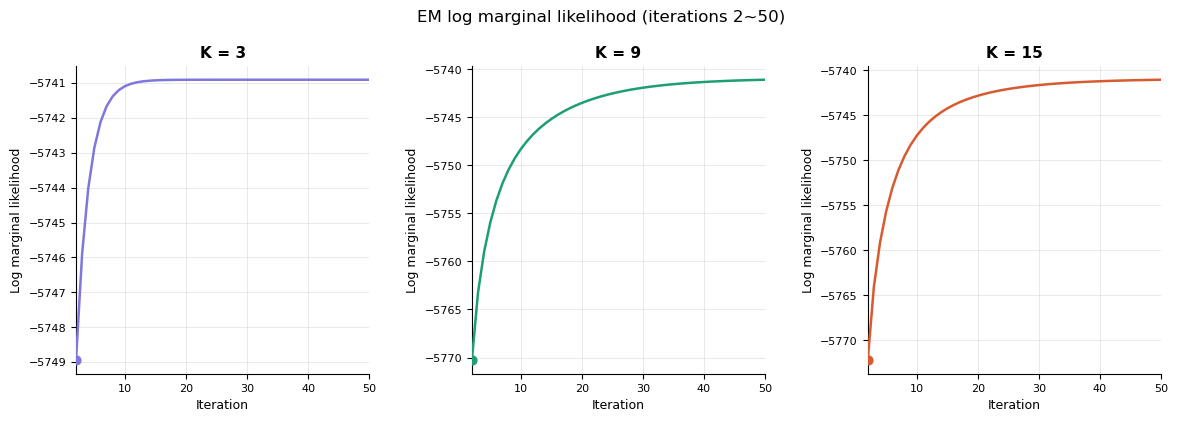

In [ ]:
#Plotting
fig = plt.figure(figsize=(14, 4))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

colors = {3: '#7F77DD', 9: '#1D9E75', 15: '#D85A30'}

for idx, K in enumerate(K_values):
    ax  = fig.add_subplot(gs[idx])
    lml = results[K]['lml']

    # Plot iterations 2–50 → indices 1–49 (0-indexed)
    iters = np.arange(2, 51)
    ax.plot(iters, lml[1:], color=colors[K], lw=1.8, zorder=3)
    ax.scatter(iters[0], lml[1], s=40, color=colors[K],
               zorder=4, label='iter 2 start')

    ax.set_title(f'K = {K}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Iteration', fontsize=9)
    ax.set_ylabel('Log marginal likelihood', fontsize=9)
    ax.set_xlim(2, 50)
    ax.tick_params(labelsize=8)
    ax.grid(True, lw=0.4, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('EM log marginal likelihood (iterations 2~50)',
             fontsize=12, y=1.02)
plt.savefig('lml_curves.pdf', bbox_inches='tight')
plt.show()

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def compute_M_matrix(pi, theta, K):
    """
    Construct the K×21 matrix M_K where M_K[k, i] = q(c=k | x=i, π, θ)
    
    Since x ∈ {0,...,20}, we evaluate p(c=k | x, π, θ) for all 21 values.
    This is exactly the E-step responsibility formula, but evaluated at
    each possible x value rather than the observed data points.
    
    M_K[k, i] = π_k · Binom(i; 20, θ_k) / Σ_j π_j · Binom(i; 20, θ_j)
    """
    x_vals = np.arange(21)          # x ∈ {0, 1, ..., 20}
    log_R = np.zeros((21, K))

    for k in range(K):
        log_R[:, k] = np.log(pi[k] + 1e-300) + binom.logpmf(x_vals, 20, theta[k])

    # Log-sum-exp normalization (same as E-step)
    log_max = log_R.max(axis=1, keepdims=True)
    shifted = np.exp(log_R - log_max)
    log_sum = np.log(shifted.sum(axis=1, keepdims=True)) + log_max

    R = np.exp(log_R - log_sum)     # shape (21, K)
    return R.T                       # shape (K, 21) = M_K


def plot_M_matrices(results, K_values):
    """
    Plot one heatmap per K value showing the K×21 responsibility matrix.
    Rows = components k, columns = x values 0..20.
    Cell colour = q(c=k | x).
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        r'$M_K(k,\, i) = q(c=k \mid x=i-1,\, \pi,\, \theta)$'
        '\nFinal EM iteration responsibilities for each K',
        fontsize=12, y=1.02
    )

    for ax, K in zip(axes, K_values):
        pi_final    = results[K]['pi']
        theta_final = results[K]['theta']

        M = compute_M_matrix(pi_final, theta_final, K)   # (K, 21)

        im = ax.imshow(
            M,
            aspect='auto',
            cmap='viridis',
            vmin=0, vmax=1,
            interpolation='nearest',
        )

        # ── Axes labels ───────────────────────────────────────
        ax.set_title(f'K = {K}', fontsize=11, fontweight='bold', pad=8)
        ax.set_xlabel('x  (observation value)', fontsize=9)
        ax.set_ylabel('Component k', fontsize=9)

        # x-axis: tick every 2 values to avoid crowding
        ax.set_xticks(np.arange(0, 21, 2))
        ax.set_xticklabels(np.arange(0, 21, 2), fontsize=7)

        # y-axis: one tick per component (suppress if K is large)
        if K <= 9:
            ax.set_yticks(np.arange(K))
            ax.set_yticklabels([f'k={k}' for k in range(K)], fontsize=7)
        else:
            ax.set_yticks(np.arange(0, K, 3))
            ax.set_yticklabels([f'k={k}' for k in range(0, K, 3)], fontsize=7)

        # ── Colorbar ──────────────────────────────────────────
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(r'$q(c=k \mid x)$', fontsize=8)
        cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.savefig('M_matrices.pdf', bbox_inches='tight')
    plt.show()




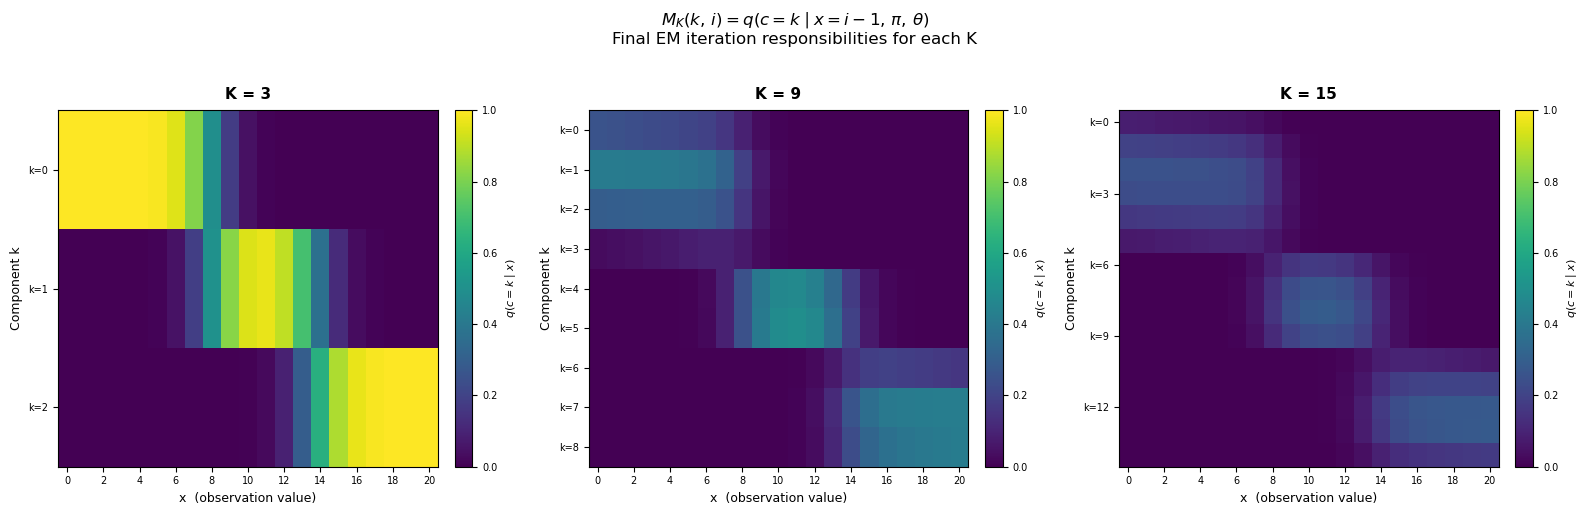

In [25]:
# ── Run ───────────────────────────────────────────────────────────────────────
# results dict is already populated from your run_em calls above
plot_M_matrices(results, K_values=[3, 9, 15])